In [29]:
import numpy as np
import pandas as pd
from scipy import stats
import math

### Create Sample Data

In [30]:
scores = np.array([55, 60, 65, 70, 72, 75, 78, 80, 85, 90])
scores

array([55, 60, 65, 70, 72, 75, 78, 80, 85, 90])

### Basic Statistics

In [31]:
mean = np.mean(scores) #calculate the mean of the scores
std_dev = np.std(scores, ddof=1)   # sample standard deviation
n = len(scores)

print("Mean:", mean)
print("Standard Deviation:", std_dev)
print("Sample Size:", n)

Mean: 73.0
Standard Deviation: 10.944303439588001
Sample Size: 10


### Standard Error (SE)

$ SE = \frac{s}{\sqrt{n}}  $

How much the sample mean varies from population mean.

In [32]:
standard_error = std_dev / math.sqrt(n)
print("Standard Error:", standard_error)

Standard Error: 3.460892627311309


### Z-Score

$  z_i = \frac{x_i - \bar{x}}{s}  $

Distance from mean measured in standard deviations.

In [33]:
z_scores = (scores - mean) / std_dev

pd.DataFrame({
    "Score": scores,
    "Z-Score": z_scores
})

,Score,Z-Score
0,55,-1.644691
1,60,-1.187833
2,65,-0.730974
3,70,-0.274115
4,72,-0.091372
5,75,0.182743
6,78,0.456859
7,80,0.639602
8,85,1.096461
9,90,1.553320


### Z-Score Table (Probability)

In [34]:
value = 80

z = (value - mean) / std_dev
probability = stats.norm.cdf(z)

print("Z value:", z)
print("Probability P(X ≤ 80):", probability)

Z value: 0.6396021490668313
Probability P(X ≤ 80): 0.7387843575192178


### Confidence Interval (95%)

$  \bar{x} \pm z \times SE  $ (z = 1.96)

In [35]:
z_value = 1.96

lower_ci = mean - z_value * standard_error
upper_ci = mean + z_value * standard_error

print("95% Confidence Interval:")
print(lower_ci, upper_ci)

95% Confidence Interval:
66.21665045046983 79.78334954953017


The 95% confidence interval suggests the true average score
likely lies between 66.2 and 79.8.

### Margin of Error

$  ME = z \times SE  $

In [36]:
margin_error = z_value * standard_error
print("Margin of Error:", margin_error)

Margin of Error: 6.783349549530166


### Hypothesis Testing (Z-Test)

Problem (Example)

Teacher claims average score = 70.

We test if this claim is true.

Null hypothesis (H₀): μ = 70

Alternative hypothesis (H₁): μ ≠ 70

Significance Level (α) = 0.05

In [37]:
mu_0 = 70
alpha = 0.05

z_stat = (mean - mu_0) / standard_error
print("Z Statistic:", z_stat)

Z Statistic: 0.866828394595597


In [38]:
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))
print("p-value:", p_value)

p-value: 0.38603604179524953


In [39]:
if p_value < alpha:
    print("Reject Null Hypothesis (H0)")
else:
    print("Fail to Reject Null Hypothesis (H0)")

Fail to Reject Null Hypothesis (H0)


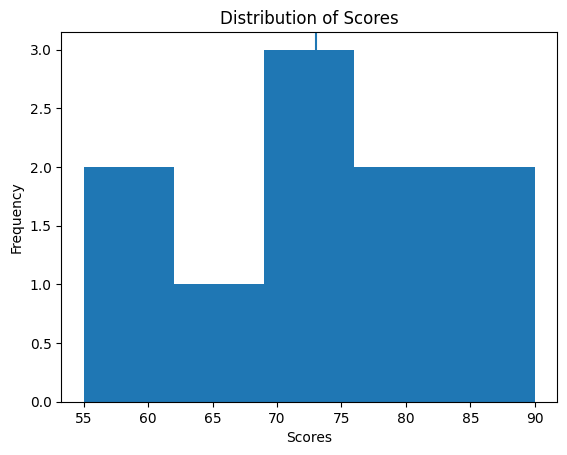

In [40]:
import matplotlib.pyplot as plt

plt.hist(scores, bins=5)
plt.axvline(mean)
plt.title("Distribution of Scores")
plt.xlabel("Scores")
plt.ylabel("Frequency")
plt.show()

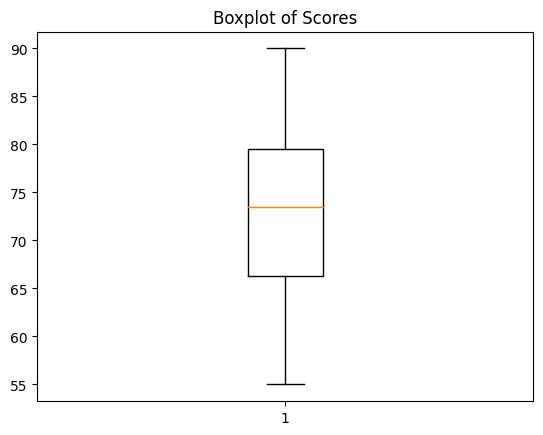

In [41]:
plt.boxplot(scores)
plt.title("Boxplot of Scores")
plt.show()

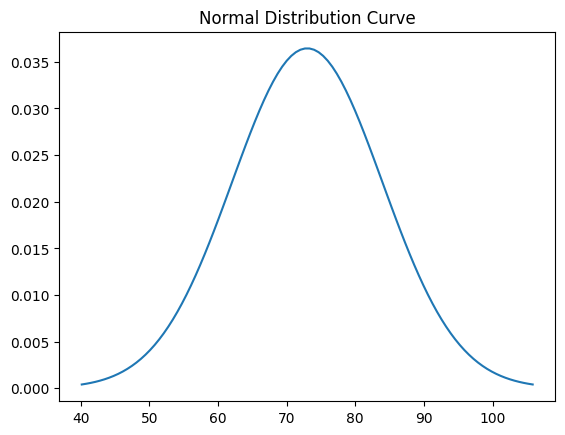

In [42]:
x = np.linspace(mean-3*std_dev, mean+3*std_dev, 100)
y = stats.norm.pdf(x, mean, std_dev)

plt.plot(x, y)
plt.title("Normal Distribution Curve")
plt.show()

### Conclusion:

The standard error quantified the uncertainty of the sample mean, allowing us to construct a 95% confidence interval to estimate the true population average. Z-scores helped standardize individual observations and calculate probabilities under the normal distribution.

Finally, hypothesis testing was performed to evaluate the teacher’s claim that the average score equals 70. Based on the calculated p-value and significance level, we made a statistical decision regarding the null hypothesis.